Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
dataset_part1.xlsx [holmes]: 100,161 rows, 53 cols
dataset_part2.xlsx [langton]: 85,022 rows, 53 cols
dataset_part3.xlsx [lego3+moorgate+silvrstone+parag]: 781 rows, 53 cols

Step 1 - merged: 185,964 rows, 53 columns

Column dtypes:
float64           29
object            10
datetime64[ns]     7
int64              7
Name: count, dtype: int64

Category codes for the numerically-coded fields (Property_Type, Purpose, Income_Verification, Interest_Rate_Type, Original/Current_Valuation_Type, Payment/Amortisation_Type) are defined by the Bank of England (2024) Loan Level Data: Reporting Template for Residential Mortgage Pools, corroborated by the ECB (2019) equivalent - both give identical definitions for every field checked. Property_Type, Purpose, and Income_Verification are used as predictors below (Step 4); Interest_Rate_Type and both Valuation_Type fields were 

/tmp/ipykernel_560/3097556523.py:64: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat(frames, ignore_index=True)
/tmp/ipykernel_560/3097556523.py:64: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat(frames, ignore_index=True)



Step 2c - rows with abnormally long/corrupted Loan_Identifier: 0
None found in the current file set.

Loan_Identifier multiplicity check: 0 loans appear more than twice (expected: at most twice, once per Pool_Cutoff_Date)

Step 2d - most common Income values:
Income
1000.0     19007
30000.0     2159
40000.0     1984
Name: count, dtype: int64
Pool_Identifier
HOLMES                           11.11
LANGTON                           9.27
LEGO3                             0.00
Moorgate 2014-1                   0.00
Paragon Mortgages (No.19) PLC     0.00
SILVRSTONE                        0.00
Name: % of pool at suspected sentinel value, dtype: float64

Step 3 - descriptive statistics on raw data
        Original_LTV  Interest_Rate      Loan_Term        Income  \
count  185826.000000   185964.00000  185964.000000  1.853670e+05   
mean       59.595611        3.55707     250.219193  4.035431e+04   
std        23.328151        1.66751      73.467736  4.549278e+04   
min         1.100000        

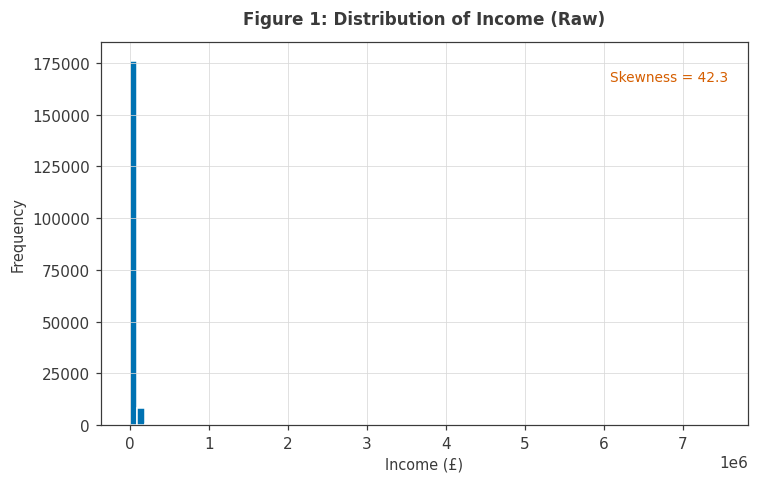

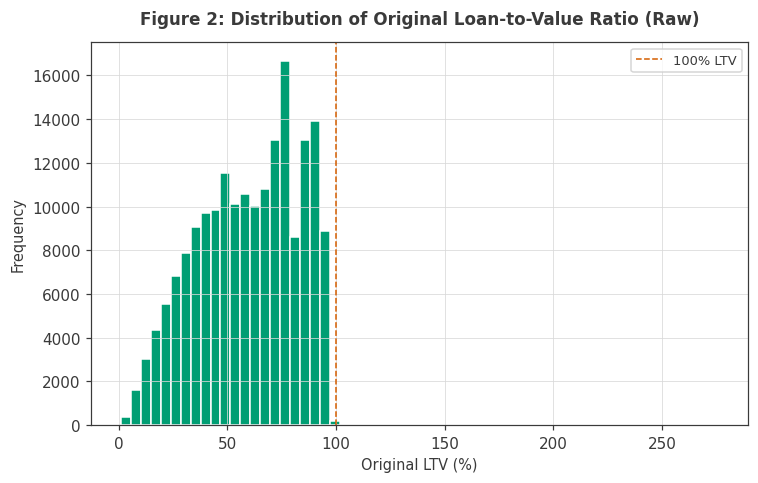

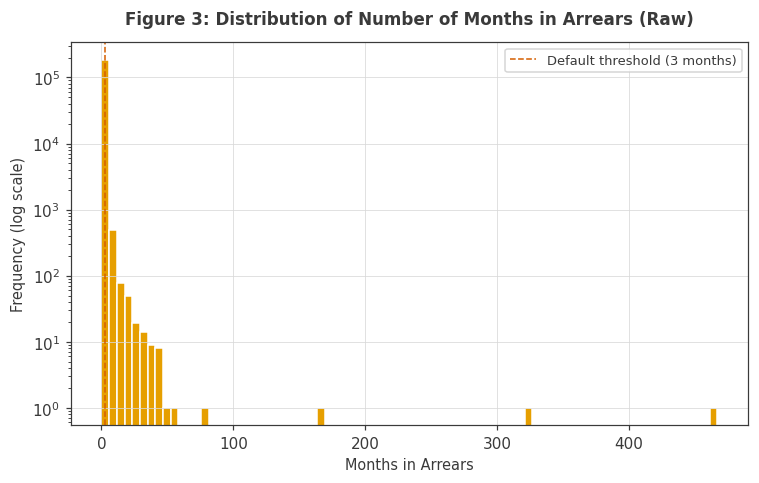

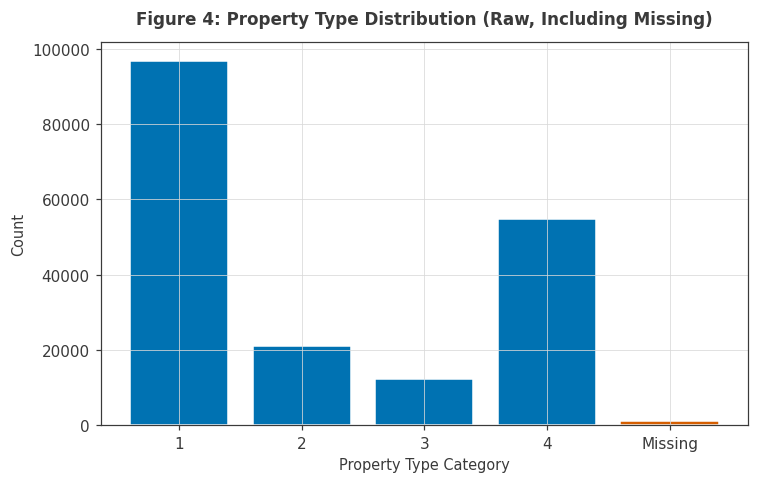

Step 4a - default flag built (NaN-preserving): 7 rows pending Step 6 removal

Step 4a (diagnostic) - arrears-based default vs raw Default field:
raw Default != 0        False  True 
arrears-based default               
0                      184035     52
1                        1849     21
Raw Default field flags 73 rows as written-off (0.039% of comparable rows). 21 of these are also >=3 months in arrears under the constructed flag. Low overlap is expected here: the two fields capture different stages (delinquency vs realized write-off), not the same event measured twice.
Step 4b - Income_log created. Post-transform skewness: -1.67 (down from 42.27, better but not fully symmetric). Coefficients on Income_log read as an approximate percentage change in Income, not a £1 change. PROVISIONAL - the Income==1000 sentinel (Step 2d) hasn't been recoded yet at this point, so this figure isn't the one to quote in the write-up; Income_log is rebuilt after Step 6g once the sentinel is removed, 

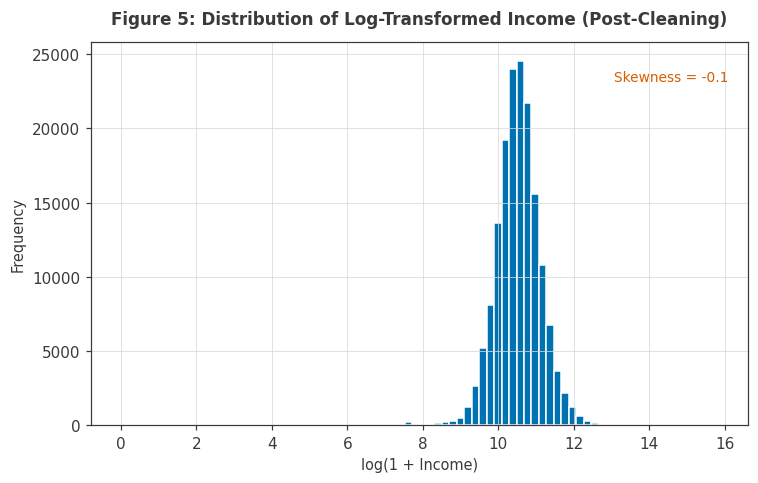

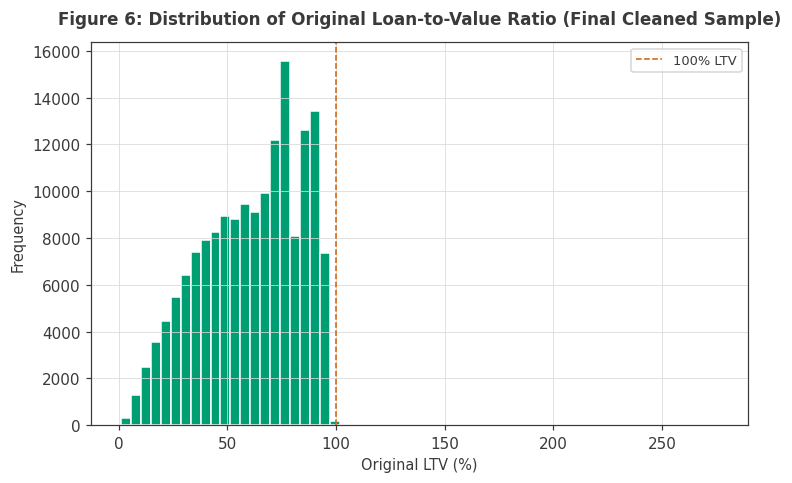

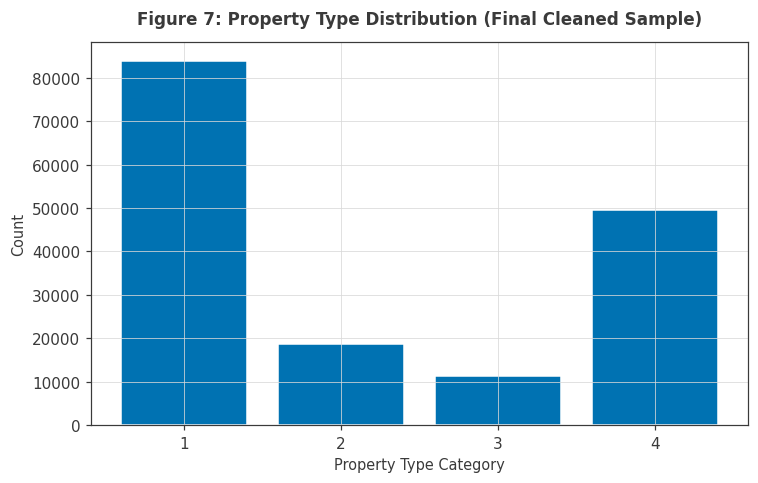

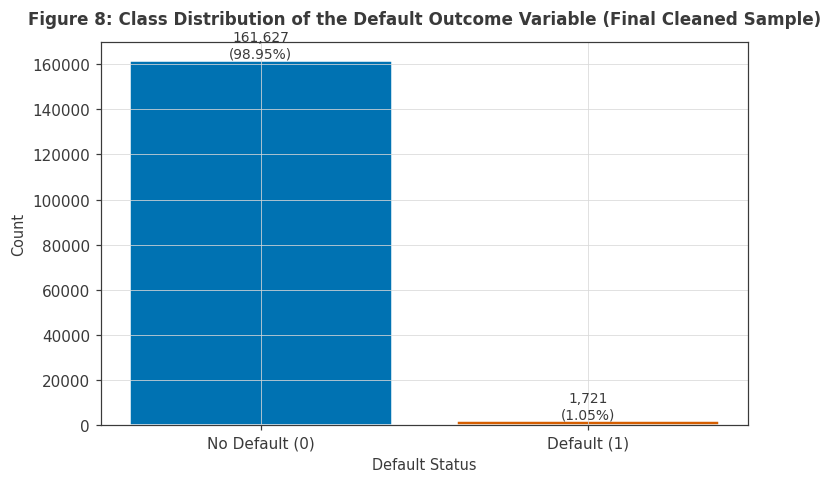

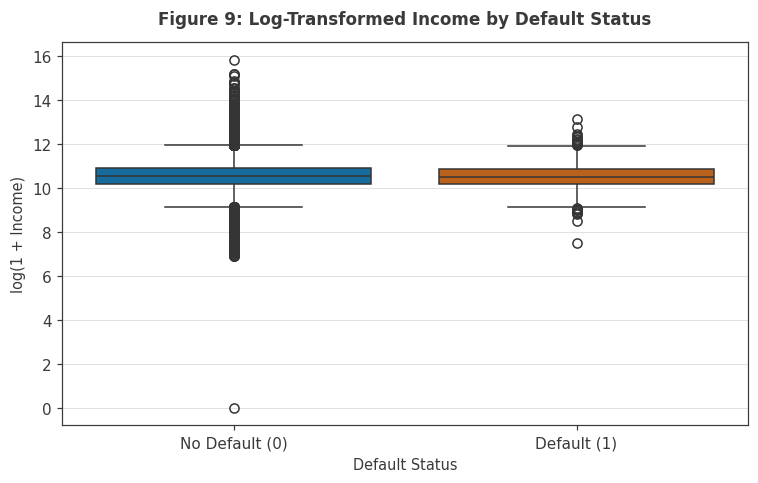

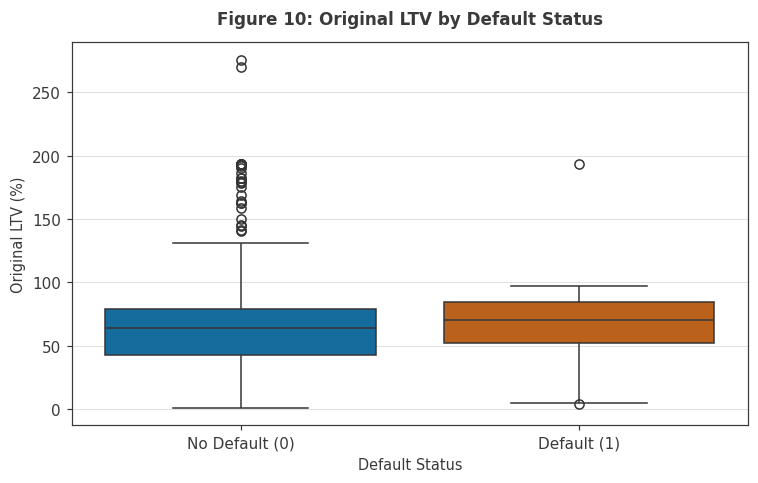


Saved cleaned dataset to /content/drive/MyDrive/Dissertation/data2/cleaned_dissertation_data.csv
Final: 163,348 rows, 61 columns


In [7]:
# Dissertation data cleaning script - UK RMBS loan-level data
# Follows the course's 8-step pre-processing sequence:
# 1. initial check, 2. large-scale problem check, 3. exploration (raw),
# 4. feature engineering, 5. outliers, 6. missing values,
# 7. repeat exploration (post-cleaning), 8. model assumptions (separate script)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns  # don't call sns.set_theme()/set_style(), it overrides the palette below
from scipy.stats import skew

from google.colab import drive
drive.mount("/content/drive")

DATA_FOLDER = "/content/drive/MyDrive/Dissertation/data2"

# Okabe-Ito colour-blind-safe palette, used for all figures
PALETTE = {
    "primary": "#0072B2",    # blue - main series, non-default class
    "highlight": "#D55E00",  # vermillion - default class, thresholds
    "secondary": "#009E73",  # bluish-green - secondary series
    "tertiary": "#E69F00",   # orange - tertiary series
    "neutral": "#3A3A3A",    # charcoal - gridlines, axis, text
}
plt.rcParams.update({
    "axes.edgecolor": PALETTE["neutral"],
    "axes.labelcolor": PALETTE["neutral"],
    "xtick.color": PALETTE["neutral"],
    "ytick.color": PALETTE["neutral"],
    "text.color": PALETTE["neutral"],
    "axes.grid": True,
    "grid.color": "#D9D9D9",
    "grid.linewidth": 0.5,
    "figure.dpi": 110,
})

FIGURE_COUNTER = {"n": 0}


def styled_figure(title, xlabel, ylabel):
    """Make a figure with consistent styling and auto-numbered title."""
    FIGURE_COUNTER["n"] += 1
    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.set_title(f"Figure {FIGURE_COUNTER['n']}: {title}",
                 fontsize=11, fontweight="bold", color=PALETTE["neutral"], pad=12)
    ax.set_xlabel(xlabel, fontsize=9.5)
    ax.set_ylabel(ylabel, fontsize=9.5)
    return fig, ax

# Step 1: load data and check format/size/documentation
file_sheets = {
    "dataset_part1.xlsx": "holmes",
    "dataset_part2.xlsx": "langton",
    "dataset_part3.xlsx": "lego3+moorgate+silvrstone+parag",  # Excel truncates sheet names at 31 chars
}

frames = []
for fname, sheet in file_sheets.items():
    df_part = pd.read_excel(f"{DATA_FOLDER}/{fname}", sheet_name=sheet)
    print(f"{fname} [{sheet}]: {df_part.shape[0]:,} rows, {df_part.shape[1]} cols")
    frames.append(df_part)

df = pd.concat(frames, ignore_index=True)
n_start = len(df)
print(f"\nStep 1 - merged: {n_start:,} rows, {df.shape[1]} columns")
print("\nColumn dtypes:")
print(df.dtypes.value_counts())
print("\nCategory codes for the numerically-coded fields (Property_Type, "
      "Purpose, Income_Verification, Interest_Rate_Type, Original/Current_"
      "Valuation_Type, Payment/Amortisation_Type) are defined by the Bank "
      "of England (2024) Loan Level Data: Reporting Template for "
      "Residential Mortgage Pools, corroborated by the ECB (2019) "
      "equivalent - both give identical definitions for every field "
      "checked. Property_Type, Purpose, and Income_Verification are used "
      "as predictors below (Step 4); Interest_Rate_Type and both "
      "Valuation_Type fields were considered and deferred (see Step 4 "
      "notes); Payment/Amortisation_Type remains unused.")

# Step 2: check for large-scale problems
# (a) variable types
print("\nStep 2a - Pool_Cutoff_Date raw values:")
print(df["Pool_Cutoff_Date"].value_counts(dropna=False))

# (b) missingness by column
print("\nStep 2b - columns with any missing values (%):")
miss_pct = (df.isna().mean() * 100).sort_values(ascending=False)
print(miss_pct[miss_pct > 0].round(1))
# Geographic_Region, DTI, Occupancy_Type are ~90%+ missing, dealt with in Step 6.

# (c) Loan_Identifier integrity check. The Bank of England (2024) template
# caps numeric loan identifiers at 15 characters; longer numeric IDs can
# also arise from Excel silently losing trailing digits on float64
# storage, so checking for both here.
suspect_ids = df["Loan_Identifier"].astype(str).str.len() > 15
print(f"\nStep 2c - rows with abnormally long/corrupted Loan_Identifier: "
      f"{suspect_ids.sum()}")
if suspect_ids.sum() > 0:
    print(df.loc[suspect_ids, ["Loan_Identifier", "Pool_Identifier",
                                "Pool_Cutoff_Date", "Number_Months_in_Arrears"]])
    print("Check the raw Excel cells directly before deciding how to treat these in Step 6.")
else:
    print("None found in the current file set.")

mult = df.groupby("Loan_Identifier").size()
print(f"\nLoan_Identifier multiplicity check: "
      f"{(mult > 2).sum()} loans appear more than twice "
      f"(expected: at most twice, once per Pool_Cutoff_Date)")

# (d) sentinel/placeholder value check on core continuous predictors. One
# value appearing far more often than any other suggests a coded "unknown"
# placeholder rather than real data.
income_top = df["Income"].value_counts().head(3)
print(f"\nStep 2d - most common Income values:\n{income_top}")
if income_top.iloc[0] > 5 * income_top.iloc[1]:
    suspect_val = income_top.index[0]
    print(f"WARNING: Income={suspect_val:g} appears "
          f"{income_top.iloc[0] / income_top.iloc[1]:.1f}x more often than "
          f"the next most common value - possible sentinel/placeholder code, "
          f"not genuine income. Dealt with in Step 6.")
    print(df.groupby("Pool_Identifier")["Income"]
          .apply(lambda g: (g == suspect_val).mean() * 100).round(2)
          .rename("% of pool at suspected sentinel value"))

# Step 3: explore the raw data before any cleaning, to justify the
# decisions made in Steps 4-6
print("\nStep 3 - descriptive statistics on raw data")
print(df[["Original_LTV", "Interest_Rate", "Loan_Term", "Income",
          "Number_Months_in_Arrears"]].describe())

raw_income_skew = skew(df["Income"].dropna())
raw_income_ratio = df["Income"].max() / df.loc[df["Income"] > 0, "Income"].min()
print(f"\nIncome (raw) skewness: {raw_income_skew:.2f} "
      f"(APM rule of thumb: max/min ratio > 20 means significant skew; "
      f"here max/min = {raw_income_ratio:,.0f})")
print("Right-skewed, motivates a log transform in Step 4.")

print(f"\nProperty_Type raw distribution:")
print(df["Property_Type"].value_counts(dropna=False))
print("Categories per BoE/ECB template: 1=House, 2=Flat, 3=Bungalow, "
      "4=Terraced. Still nominal (no implied order between them), so "
      "dummy-encoded as unordered categories in Step 4 regardless of "
      "the codes being known.")

# Figure 1: Income (raw)
fig, ax = styled_figure(
    "Distribution of Income (Raw)", "Income (£)", "Frequency"
)
ax.hist(df["Income"].dropna(), bins=80, color=PALETTE["primary"], edgecolor="white")
ax.text(0.97, 0.90, f"Skewness = {raw_income_skew:.1f}",
        transform=ax.transAxes, ha="right", fontsize=9, color=PALETTE["highlight"])
plt.tight_layout()
plt.savefig(f"{DATA_FOLDER}/fig1_income_raw.png", bbox_inches="tight")
plt.show()

# Figure 2: Original_LTV (raw)
fig, ax = styled_figure(
    "Distribution of Original Loan-to-Value Ratio (Raw)",
    "Original LTV (%)", "Frequency"
)
ax.hist(df["Original_LTV"].dropna(), bins=60, color=PALETTE["secondary"],
        edgecolor="white")
ax.axvline(100, color=PALETTE["highlight"], linestyle="--", linewidth=1,
           label="100% LTV")
ax.legend(fontsize=8.5)
plt.tight_layout()
plt.savefig(f"{DATA_FOLDER}/fig2_ltv_raw.png", bbox_inches="tight")
plt.show()

# Figure 3: Number_Months_in_Arrears (raw), log y-scale since most values
# sit at 0 with a long right tail
fig, ax = styled_figure(
    "Distribution of Number of Months in Arrears (Raw)",
    "Months in Arrears", "Frequency (log scale)"
)
ax.hist(df["Number_Months_in_Arrears"].dropna(), bins=80, color=PALETTE["tertiary"],
        edgecolor="white")
ax.set_yscale("log")
ax.axvline(3, color=PALETTE["highlight"], linestyle="--", linewidth=1,
           label="Default threshold (3 months)")
ax.legend(fontsize=8.5)
plt.tight_layout()
plt.savefig(f"{DATA_FOLDER}/fig3_arrears_raw.png", bbox_inches="tight")
plt.show()

# Figure 4: Property_Type distribution (raw, including missing)
fig, ax = styled_figure(
    "Property Type Distribution (Raw, Including Missing)",
    "Property Type Category", "Count"
)
pt_counts = df["Property_Type"].value_counts(dropna=False).sort_index()
pt_labels = [str(int(i)) if pd.notna(i) else "Missing" for i in pt_counts.index]
bar_colors = [PALETTE["primary"] if lbl != "Missing" else PALETTE["highlight"]
              for lbl in pt_labels]
ax.bar(pt_labels, pt_counts.values, color=bar_colors, edgecolor="white")
plt.tight_layout()
plt.savefig(f"{DATA_FOLDER}/fig4_proptype_raw.png", bbox_inches="tight")
plt.show()

# Step 4: feature engineering (dummy encoding, transformations)

# 4a. Build the default flag from Number_Months_in_Arrears. Using np.where
# instead of a plain comparison, since NaN >= 3 evaluates to False in
# pandas and would wrongly mark missing-arrears rows as non-default.
df["default"] = np.where(
    df["Number_Months_in_Arrears"].isna(),
    np.nan,
    (df["Number_Months_in_Arrears"] >= 3).astype(float),
)
print(f"Step 4a - default flag built (NaN-preserving): "
      f"{df['default'].isna().sum():,} rows pending Step 6 removal")

# check the constructed flag against the raw Default/Default_Date fields,
# which the rest of this script doesn't otherwise use. Default holds a
# write-off amount (0 = no write-off), not a delinquency flag, so this
# isn't expected to match closely, but worth confirming and quantifying
# rather than leaving unexamined.
has_raw_default = df["Default"].fillna(0) != 0
comparable = df["default"].notna()
crosstab = pd.crosstab(
    df.loc[comparable, "default"].astype(int),
    has_raw_default[comparable],
    rownames=["arrears-based default"], colnames=["raw Default != 0"]
)
print("\nStep 4a (diagnostic) - arrears-based default vs raw Default field:")
print(crosstab)
n_raw_default = has_raw_default[comparable].sum()
n_overlap = ((df.loc[comparable, "default"] == 1) & has_raw_default[comparable]).sum()
print(f"Raw Default field flags {n_raw_default:,} rows as written-off "
      f"({n_raw_default / comparable.sum():.3%} of comparable rows). "
      f"{n_overlap:,} of these are also >=3 months in arrears under the "
      f"constructed flag. Low overlap is expected here: the two fields "
      f"capture different stages (delinquency vs realized write-off), "
      f"not the same event measured twice.")

# 4b. Log-transform Income (log1p, not log, since Income can be 0)
df["Income_log"] = np.log1p(df["Income"])
log_income_skew = skew(df["Income_log"].dropna())
print(f"Step 4b - Income_log created. Post-transform skewness: "
      f"{log_income_skew:.2f} (down from {raw_income_skew:.2f}, "
      f"better but not fully symmetric). Coefficients on Income_log read "
      f"as an approximate percentage change in Income, not a £1 change. "
      f"PROVISIONAL - the Income==1000 sentinel (Step 2d) hasn't been "
      f"recoded yet at this point, so this figure isn't the one to quote "
      f"in the write-up; Income_log is rebuilt after Step 6g once the "
      f"sentinel is removed, and Step 7 reports the real final skewness.")

# 4c. Dummy-encode Property_Type. Categories per BoE/ECB template: House
# (detached/semi-detached), Flat, Bungalow, Terraced. Nominal - no
# implied order between them, so dummy encoding is required regardless
# of the codes being known (a raw numeric code would falsely imply equal
# spacing and a monotonic relationship with risk). dummy_na=True keeps
# missing rows visible instead of silently folding them into the
# reference category; they get dropped properly in Step 6.
# get_dummies defaults to drop_first=False, so it keeps a column for
# every category, which causes perfect collinearity with the intercept
# in logistic regression. Dropping the reference column below to avoid
# that. House is used as reference: it's the largest category (roughly
# half the sample), which minimises the standard errors on the other
# category coefficients, and is the standard/most typical property type.
proptype_labels = {1.0: "House", 2.0: "Flat", 3.0: "Bungalow", 4.0: "Terraced"}
proptype_dummies = pd.get_dummies(
    df["Property_Type"].map(proptype_labels), prefix="PropType",
    dummy_na=True, dtype=int
)
reference_col = "PropType_House"
assert reference_col in proptype_dummies.columns, (
    f"Expected reference column {reference_col} not found, check "
    f"Property_Type's coding before proceeding."
)
proptype_dummies = proptype_dummies.drop(columns=[reference_col])
print(f"Step 4c - Property_Type dummy-encoded (reference={reference_col} "
      f"excluded): {list(proptype_dummies.columns)}")
df = pd.concat([df, proptype_dummies], axis=1)

# 4d. Dummy-encode Purpose. Debt consolidation and equity-release
# re-mortgages are specifically flagged in the mortgage default
# literature as elevated-risk purposes (borrowers extracting equity or
# consolidating other debt are plausibly already under financial
# pressure - see e.g. Mian & Sufi on home equity extraction and
# default), so this is a theoretically-motivated addition, not just
# because the codes are now known. Categories under 1% of the raw
# sample (Equity release, Right to Buy, Construction, Re-mortgage on
# Different Terms) are folded into the existing "Other" code first,
# since a handful of loans can't support a stable coefficient (same
# near-zero-variance concern as APM Sect. 3.5). Purchase used as
# reference (largest category). dummy_na=True/Step 6 handling mirrors
# Property_Type above.
purpose_counts = df["Purpose"].value_counts()
purpose_rare_codes = purpose_counts[purpose_counts < 0.01 * n_start].index.tolist()
print(f"Step 4d - Purpose codes folded into Other (each <1% of raw sample): "
      f"{purpose_rare_codes}")
df["Purpose_grouped"] = df["Purpose"].replace(purpose_rare_codes, 7.0)
purpose_labels = {
    1.0: "Purchase", 2.0: "Remortgage", 3.0: "Renovation",
    6.0: "DebtConsolidation", 8.0: "RemortgageEquityRelease", 7.0: "Other",
}
purpose_dummies = pd.get_dummies(
    df["Purpose_grouped"].map(purpose_labels), prefix="Purpose",
    dummy_na=True, dtype=int
)
reference_col = "Purpose_Purchase"
assert reference_col in purpose_dummies.columns, (
    f"Expected reference column {reference_col} not found, check "
    f"Purpose's coding before proceeding."
)
purpose_dummies = purpose_dummies.drop(columns=[reference_col])
print(f"Step 4d - Purpose dummy-encoded (reference={reference_col} "
      f"excluded): {list(purpose_dummies.columns)}")
df = pd.concat([df.drop(columns=["Purpose_grouped"]), purpose_dummies], axis=1)

# 4e. Dummy-encode Income_Verification. Verification quality is one of
# the most heavily studied default mechanisms in the mortgage crisis
# literature (overstated, unverified income predicts elevated default
# in low-doc/no-doc loan studies) - the regulatory rationale behind the
# UK's 2014 Mortgage Market Review affordability rules. True
# self-certified (code 1) is negligible here (7 rows, consistent with
# self-cert being phased out ahead of MMR) and folded into "Other" for
# stability. Verified used as reference (largest category, and the
# substantive baseline - "Other" is the theorised elevated-risk group).
income_ver_labels = {3.0: "Verified", 5.0: "Other", 1.0: "Other"}
income_ver_dummies = pd.get_dummies(
    df["Income_Verification"].map(income_ver_labels), prefix="IncVerif",
    dummy_na=True, dtype=int
)
reference_col = "IncVerif_Verified"
assert reference_col in income_ver_dummies.columns, (
    f"Expected reference column {reference_col} not found, check "
    f"Income_Verification's coding before proceeding."
)
income_ver_dummies = income_ver_dummies.drop(columns=[reference_col])
print(f"Step 4e - Income_Verification dummy-encoded (reference="
      f"{reference_col} excluded): {list(income_ver_dummies.columns)}")
df = pd.concat([df, income_ver_dummies], axis=1)

# Interest_Rate_Type and Original/Current_Valuation_Type were considered
# and deferred, not overlooked. Interest_Rate_Type has two categories
# under 0.3% of the sample that would need collapsing (deferred on time
# grounds, not ruled out for future robustness checks). Current_
# Valuation_Type is ~92% one category (near-zero-variance, APM Sect.
# 3.5) - excluded. Original_Valuation_Type has more spread but reflects
# how LTV was measured, not a behavioural driver of default - excluded
# from the model, noted instead as an LTV measurement-reliability
# limitation in the write-up.

# Step 5: outliers

# Number_Months_in_Arrears has extreme values (max ~467 months) but the
# binary default flag already collapses anything >=3, so magnitude
# doesn't affect the outcome. Left untouched.
max_arrears = df["Number_Months_in_Arrears"].max()
n_extreme_arrears = (df["Number_Months_in_Arrears"] > 60).sum()
print(f"Step 5a - Number_Months_in_Arrears: max = {max_arrears:.0f}, "
      f"{n_extreme_arrears:,} rows exceed 60 months. Left untouched.")

# Original_LTV: checked for implausible values (>150% or <=0%). High LTVs
# are plausible in a post-2008 negative-equity context, not necessarily
# errors. Left untouched.
n_high_ltv = (df["Original_LTV"] > 150).sum()
n_invalid_ltv = (df["Original_LTV"] <= 0).sum()
print(f"Step 5b - Original_LTV: {n_high_ltv} rows exceed 150% "
      f"(plausible under negative equity); {n_invalid_ltv} rows <=0 "
      f"(would be an error, none found). Left untouched.")

# Income: outliers above £1,000,000 were already handled by the log
# transform in Step 4, not by removal here. That's why transformation
# comes before outlier review in this sequence.
n_high_income = (df["Income"] > 1_000_000).sum()
print(f"Step 5c - Income: {n_high_income} raw rows exceed £1,000,000, "
      f"handled by the Step 4 log transform, not removed.")

# Step 6: missing values
n_before = len(df)

# 6a. drop structurally near-empty columns found in Step 2b
cols_to_drop = ["Geographic_Region", "DTI", "Occupancy_Type"]
df = df.drop(columns=cols_to_drop)
print(f"Step 6a - dropped columns (structurally missing): {cols_to_drop}")

# 6b. drop rows where the outcome is undefined, before restructuring the
# panel below, since risk-set membership depends on default being defined
n_before_default_drop = len(df)
df = df.dropna(subset=["default"])
df["default"] = df["default"].astype(int)
n_default_dropped = n_before_default_drop - len(df)
print(f"Step 6b - dropped {n_default_dropped:,} rows missing "
      f"Number_Months_in_Arrears (default undefined)")

# 6c. resolve panel duplicates to one row per loan (cross-sectional).
# Only the HOLMES pool reports at both 2014 Q4 and 2015 Q1; every other
# pool reports at a single date, so a genuine two-period panel only
# exists for a small, structurally-confined subset of loans (3,613 of
# 182,351, ~2%) - not enough to support a discrete-time hazard
# specification, which was tried and dropped for this reason. Instead:
# sort so that, within each loan, a defaulting snapshot sorts before a
# non-defaulting one, and the most recent snapshot sorts before an
# older one - then keep the first row per loan. This keeps a default
# if either snapshot has one (so a loan that defaulted early and looks
# cured later isn't silently lost), and prefers the most recent
# snapshot as the tie-break otherwise. In practice this makes no
# difference to the model here: Original_LTV, Income, and Interest_Rate
# are identical across both snapshots for every one of these loans, and
# Loan_Term differs for only 31 of 3,613 - these are static,
# origination-time fields in this dataset, not ones that update
# per-quarter.
df["Pool_Cutoff_Date"] = df["Pool_Cutoff_Date"].astype(str)
df = df.sort_values(
    ["Loan_Identifier", "default", "Pool_Cutoff_Date"],
    ascending=[True, False, False],
)
n_before_dedup = len(df)
df = df.drop_duplicates(subset="Loan_Identifier", keep="first")
n_dupes_dropped = n_before_dedup - len(df)
print(f"Step 6c - resolved to one row per loan: {n_dupes_dropped:,} "
      f"duplicate-loan rows dropped, defaulting snapshot kept where one "
      f"exists, most recent snapshot kept otherwise")

# 6d. drop rows missing Property_Type. Not imputed, since it's the central
# predictor for the research question and imputing it risks circularity.
n_before_pt_drop = len(df)
df = df[df["PropType_nan"] == 0].drop(columns=["PropType_nan"])
n_pt_dropped = n_before_pt_drop - len(df)
print(f"Step 6d - dropped {n_pt_dropped:,} rows missing Property_Type")

# 6e. drop rows missing Purpose. Small share of the sample (~1%), so
# dropping is a cheap way to avoid treating "missing" as if it were a
# substantive category alongside genuine purposes.
n_before_purpose_drop = len(df)
df = df[df["Purpose_nan"] == 0].drop(columns=["Purpose_nan"])
n_purpose_dropped = n_before_purpose_drop - len(df)
print(f"Step 6e - dropped {n_purpose_dropped:,} rows missing Purpose")

# 6f. drop rows missing Income_Verification. Smaller share still (~0.3%).
# Checked whether this missingness is informative: it's not random -
# all 597 rows missing Income_Verification (and Income) are the exact
# same rows, and all 597 belong to a single pool, Paragon Mortgages
# (~80% of that pool's 750 loans). Paragon's default rate is 0% across
# its entire pool, not specifically among the missing rows, so this
# looks like a pool-level effect (plausibly loan seasoning - Paragon
# only reports at 2015 Q1, so these may be too recently originated to
# have reached 3 months arrears yet) that happens to coincide with the
# missingness, rather than verification status itself driving default.
# This is why the rows are dropped rather than imputed: imputing income
# for a structurally distinct, near-entirely-non-reporting pool by
# borrowing patterns from HOLMES/LANGTON would import a mismatched
# income distribution from a different originator, not recover the
# true value.
n_before_incverif_drop = len(df)
df = df[df["IncVerif_nan"] == 0].drop(columns=["IncVerif_nan"])
n_incverif_dropped = n_before_incverif_drop - len(df)
print(f"Step 6f - dropped {n_incverif_dropped:,} rows missing "
      f"Income_Verification")

# 6g. recode the Income sentinel value (found in Step 2d) to missing.
# Income == 1000 appears ~9.5x more often than the next most common
# value, mostly in HOLMES/LANGTON, and has a noticeably different default
# rate (0.59% vs 1.05%) from the rest of the sample - looks like a
# placeholder for unknown/undisclosed income, not a real £1,000 income.
# Recoded to NaN rather than dropped directly, so it gets caught by the
# core-predictor missingness drop in 6h.
n_sentinel = (df["Income"] == 1000).sum()
df.loc[df["Income"] == 1000, "Income"] = np.nan
print(f"Step 6g - recoded {n_sentinel:,} rows with Income == 1000 "
      f"(suspected sentinel value) to missing")

# 6h. drop rows missing a core continuous predictor (including the
# recoded sentinel rows from 6g)
core_predictors = ["Original_LTV", "Interest_Rate", "Loan_Term", "Income"]
n_before_predictor_drop = len(df)
df = df.dropna(subset=core_predictors)
n_predictor_dropped = n_before_predictor_drop - len(df)
print(f"Step 6h - dropped {n_predictor_dropped:,} rows missing a core "
      f"continuous predictor (including recoded sentinel rows)")

# rebuild Income_log here, since the Step 4b version was computed before
# the Step 6g recode existed and would carry a stale log1p(1000) value
df["Income_log"] = np.log1p(df["Income"])

n_after = len(df)
print(f"\nStep 6 total: {n_before:,} -> {n_after:,} rows "
      f"({n_before - n_after:,} dropped)")

# Step 7: repeat descriptive stats/plots after cleaning, to check the
# cleaning steps didn't introduce unexpected changes
print("\nStep 7 - post-intervention descriptive statistics")
print(df[["Original_LTV", "Interest_Rate", "Loan_Term", "Income_log"]].describe())

final_income_log_skew = skew(df["Income_log"])
print(f"\nIncome_log skewness (final): {final_income_log_skew:.2f}. Not "
      f"expected to match Step 4b's provisional {log_income_skew:.2f} - "
      f"the gap between them is the sentinel recode (Step 6g) correctly "
      f"taking effect, not row-drop selection. This final figure, not "
      f"Step 4b's, is the one to report in the write-up.")

print(f"\nFinal default rate: {df['default'].mean():.2%} "
      f"({df['default'].sum():,} events / {len(df):,} rows)")

print("\nProperty_Type distribution, post-cleaning (compare to Step 3):")
print(df["Property_Type"].value_counts())

# Figure 5: Income_log (post-transform, final sample), compare to Figure 1
fig, ax = styled_figure(
    "Distribution of Log-Transformed Income (Post-Cleaning)",
    "log(1 + Income)", "Frequency"
)
ax.hist(df["Income_log"], bins=80, color=PALETTE["primary"], edgecolor="white")
ax.text(0.97, 0.90, f"Skewness = {final_income_log_skew:.1f}",
        transform=ax.transAxes, ha="right", fontsize=9, color=PALETTE["highlight"])
plt.tight_layout()
plt.savefig(f"{DATA_FOLDER}/fig5_income_log_final.png", bbox_inches="tight")
plt.show()

# Figure 6: Original_LTV (final sample), compare to Figure 2
fig, ax = styled_figure(
    "Distribution of Original Loan-to-Value Ratio (Final Cleaned Sample)",
    "Original LTV (%)", "Frequency"
)
ax.hist(df["Original_LTV"], bins=60, color=PALETTE["secondary"], edgecolor="white")
ax.axvline(100, color=PALETTE["highlight"], linestyle="--", linewidth=1,
           label="100% LTV")
ax.legend(fontsize=8.5)
plt.tight_layout()
plt.savefig(f"{DATA_FOLDER}/fig6_ltv_final.png", bbox_inches="tight")
plt.show()

# Figure 7: Property_Type distribution (final sample), compare to Figure 4
fig, ax = styled_figure(
    "Property Type Distribution (Final Cleaned Sample)",
    "Property Type Category", "Count"
)
pt_counts_final = df["Property_Type"].value_counts().sort_index()
ax.bar([str(int(i)) for i in pt_counts_final.index], pt_counts_final.values,
       color=PALETTE["primary"], edgecolor="white")
plt.tight_layout()
plt.savefig(f"{DATA_FOLDER}/fig7_proptype_final.png", bbox_inches="tight")
plt.show()

# Figure 8: class distribution of the outcome variable, shows the
# rare-event imbalance that motivates class-weighting/PR-AUC choices later
fig, ax = styled_figure(
    "Class Distribution of the Default Outcome Variable (Final Cleaned Sample)",
    "Default Status", "Count"
)
default_counts = df["default"].value_counts().sort_index()
ax.bar(["No Default (0)", "Default (1)"], default_counts.values,
       color=[PALETTE["primary"], PALETTE["highlight"]], edgecolor="white")
for i, v in enumerate(default_counts.values):
    ax.text(i, v, f"{v:,}\n({v/len(df):.2%})", ha="center", va="bottom",
            fontsize=9, color=PALETTE["neutral"])
plt.tight_layout()
plt.savefig(f"{DATA_FOLDER}/fig8_default_class_balance.png", bbox_inches="tight")
plt.show()

# Step 7b: predictor vs. outcome, bivariate check
# Not a Step 7 repeat check, since default doesn't exist before Step 4 so
# there's no Step 3 "before" version to compare to. This is a first look
# at whether Income_log and Original_LTV separate the two classes, to
# help justify predictor choice at the modelling stage.

# Figure 9: Income_log by default status
fig, ax = styled_figure(
    "Log-Transformed Income by Default Status", "Default Status", "log(1 + Income)"
)
sns.boxplot(data=df, x="default", y="Income_log", hue="default", legend=False,
            palette=[PALETTE["primary"], PALETTE["highlight"]], ax=ax)
ax.set_xticks([0, 1])
ax.set_xticklabels(["No Default (0)", "Default (1)"])
plt.tight_layout()
plt.savefig(f"{DATA_FOLDER}/fig9_income_log_by_default.png", bbox_inches="tight")
plt.show()

# Figure 10: Original_LTV by default status
fig, ax = styled_figure(
    "Original LTV by Default Status", "Default Status", "Original LTV (%)"
)
sns.boxplot(data=df, x="default", y="Original_LTV", hue="default", legend=False,
            palette=[PALETTE["primary"], PALETTE["highlight"]], ax=ax)
ax.set_xticks([0, 1])
ax.set_xticklabels(["No Default (0)", "Default (1)"])
plt.tight_layout()
plt.savefig(f"{DATA_FOLDER}/fig10_ltv_by_default.png", bbox_inches="tight")
plt.show()

# Step 8: model assumptions and choice of technique are done in the
# modelling script (VIF, Hosmer-Lemeshow etc), not here

output_name = f"{DATA_FOLDER}/cleaned_dissertation_data.csv"
df.to_csv(output_name, index=False)
print(f"\nSaved cleaned dataset to {output_name}")
print(f"Final: {len(df):,} rows, {df.shape[1]} columns")


In [8]:
# Step 9: alternative cleaned samples for preprocessing-choice robustness
# Two Step 6 decisions are judgement calls that a reader could reasonably
# have made differently, and both touch the outcome variable directly:
#
#   (a) Step 6c resolves dual-snapshot loans by preferring a DEFAULTING
#       snapshot over a non-defaulting one. This is outcome-dependent
#       selection: it gives the 3,613 HOLMES loans observed twice a
#       two-quarter ascertainment window, while every other loan gets one
#       quarter. The alternative rule (keep the most recent snapshot
#       regardless of default status) applies a uniform one-quarter window
#       to every loan.
#
#   (b) Step 6g/6h recodes and then drops the Income == 1000 sentinel rows.
#       That deletion is not random with respect to either the outcome
#       (sentinel rows default at ~0.6% vs ~1.05% for the rest) or the
#       focal RQ1 predictor (sentinel rows are ~11.8% of Houses but only
#       ~7.5-8.4% of Flats/Bungalows/Terraced). Because House is the
#       reference category, a deletion that strips proportionally more
#       low-risk rows out of the reference group than out of the comparison
#       groups can bias every Property_Type odds ratio. The alternative is
#       to retain those rows and drop Income from the specification instead
#       - defensible because Income_log is not significant in the baseline
#       model, so the sample is worth more than the predictor.
#
# Neither alternative replaces the main pipeline. Both are written out here
# so the modelling script can refit on them and report whether RQ1's answer
# depends on either choice (see logistic_regression_model.ipynb, Step 5c).
#
# The rebuild below is a compact re-implementation of Steps 4-6, not a call
# back into the pipeline above (which mutates `df` in place and cannot be
# re-run with different settings). Its correctness is verified by an assert:
# under the as-built settings it must reproduce the main sample exactly
# (163,348 rows, 1,721 events). If that assert passes, the two alternative
# samples differ from the main one only in the setting being varied.

def build_alternative_sample(dedup_rule="default_first", drop_income_sentinel=True):
    """Rebuild the cleaned sample under alternative Step 6 rules.

    dedup_rule: "default_first" (as built) or "latest" (most recent
                snapshot only, regardless of default status).
    drop_income_sentinel: True (as built) or False (retain the
                Income == 1000 rows; Income is then unusable as a predictor).
    """
    global _raw_cache
    if "_raw_cache" not in globals():
        # parse the Excel files once and reuse - this function is called
        # three times below and re-reading ~186k rows each time is the
        # difference between a fast cell and a several-minute one
        frames_alt = []
        for fname_alt, sheet_alt in file_sheets.items():
            frames_alt.append(pd.read_excel(f"{DATA_FOLDER}/{fname_alt}",
                                            sheet_name=sheet_alt))
        _raw_cache = pd.concat(frames_alt, ignore_index=True)
    d = _raw_cache.copy()
    n_raw = len(d)

    # Step 4a equivalent
    d["default"] = np.where(
        d["Number_Months_in_Arrears"].isna(), np.nan,
        (d["Number_Months_in_Arrears"] >= 3).astype(float),
    )

    # Step 4c-4e equivalents (same labels, same rare-category rule)
    d["PT_label"] = d["Property_Type"].map(
        {1.0: "House", 2.0: "Flat", 3.0: "Bungalow", 4.0: "Terraced"})
    pc = d["Purpose"].value_counts()
    rare = pc[pc < 0.01 * n_raw].index.tolist()
    d["Purpose_label"] = d["Purpose"].replace(rare, 7.0).map({
        1.0: "Purchase", 2.0: "Remortgage", 3.0: "Renovation",
        6.0: "DebtConsolidation", 8.0: "RemortgageEquityRelease", 7.0: "Other"})
    d["IncVerif_label"] = d["Income_Verification"].map(
        {3.0: "Verified", 5.0: "Other", 1.0: "Other"})

    # Step 6b
    d = d.dropna(subset=["default"])

    # Step 6c, under the requested rule
    d["Pool_Cutoff_Date"] = d["Pool_Cutoff_Date"].astype(str)
    if dedup_rule == "default_first":
        d = d.sort_values(["Loan_Identifier", "default", "Pool_Cutoff_Date"],
                          ascending=[True, False, False])
    elif dedup_rule == "latest":
        d = d.sort_values(["Loan_Identifier", "Pool_Cutoff_Date"],
                          ascending=[True, False])
    else:
        raise ValueError(f"unknown dedup_rule: {dedup_rule}")
    d = d.drop_duplicates(subset="Loan_Identifier", keep="first")

    # Step 6g
    if drop_income_sentinel:
        d.loc[d["Income"] == 1000, "Income"] = np.nan
    d["Income_log"] = np.log1p(d["Income"])

    # Steps 6d-6f and 6h
    required = ["PT_label", "Purpose_label", "IncVerif_label",
                "Original_LTV", "Interest_Rate", "Loan_Term"]
    if drop_income_sentinel:
        required = required + ["Income"]
    d = d.dropna(subset=required)
    d["default"] = d["default"].astype(int)

    # dummy blocks, same reference categories as Step 4
    for prefix, col, ref in [("PropType", "PT_label", "PropType_House"),
                             ("Purpose", "Purpose_label", "Purpose_Purchase"),
                             ("IncVerif", "IncVerif_label", "IncVerif_Verified")]:
        dummies = pd.get_dummies(d[col], prefix=prefix, dtype=int)
        assert ref in dummies.columns, f"reference column {ref} missing"
        d = pd.concat([d, dummies.drop(columns=[ref])], axis=1)
    return d


# verification: the as-built settings must reproduce the main sample exactly
check = build_alternative_sample(dedup_rule="default_first",
                                 drop_income_sentinel=True)
print(f"Step 9 verification - rebuild under as-built settings: "
      f"{len(check):,} rows, {check['default'].sum():,} events")
assert len(check) == len(df), (
    f"rebuild produced {len(check):,} rows vs the main pipeline's {len(df):,} "
    f"- the compact rebuild has drifted from Steps 4-6 and must be fixed "
    f"before its output is trusted"
)
assert check["default"].sum() == df["default"].sum(), "event count mismatch"
print("Matches the main pipeline exactly - the rebuild is a faithful "
      "re-implementation, so differences in the samples below are "
      "attributable to the varied setting alone.")

alt_latest = build_alternative_sample(dedup_rule="latest",
                                      drop_income_sentinel=True)
alt_sentinel = build_alternative_sample(dedup_rule="default_first",
                                        drop_income_sentinel=False)

print(f"\nAlternative A - most-recent-snapshot rule: {len(alt_latest):,} rows, "
      f"{alt_latest['default'].sum():,} events "
      f"({alt_latest['default'].mean():.3%}). The event-count difference "
      f"against the main sample is the number of defaults that exist only "
      f"because the two-quarter window was applied to the HOLMES loans "
      f"observed twice.")
print(f"Alternative B - Income sentinel retained: {len(alt_sentinel):,} rows, "
      f"{alt_sentinel['default'].sum():,} events "
      f"({alt_sentinel['default'].mean():.3%}). Income is not usable as a "
      f"predictor in this sample and is dropped from the specification when "
      f"it is refitted.")

alt_latest.to_csv(f"{DATA_FOLDER}/cleaned_alt_latest_snapshot.csv", index=False)
alt_sentinel.to_csv(f"{DATA_FOLDER}/cleaned_alt_sentinel_retained.csv", index=False)
print(f"\nSaved both alternative samples to {DATA_FOLDER}/ for use in the "
      f"modelling script's Step 5c robustness section.")


/tmp/ipykernel_560/2044697560.py:53: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  _raw_cache = pd.concat(frames_alt, ignore_index=True)
/tmp/ipykernel_560/2044697560.py:53: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  _raw_cache = pd.concat(frames_alt, ignore_index=True)


Step 9 verification - rebuild under as-built settings: 163,348 rows, 1,721 events
Matches the main pipeline exactly - the rebuild is a faithful re-implementation, so differences in the samples below are attributable to the varied setting alone.

Alternative A - most-recent-snapshot rule: 163,348 rows, 1,702 events (1.042%). The event-count difference against the main sample is the number of defaults that exist only because the two-quarter window was applied to the HOLMES loans observed twice.
Alternative B - Income sentinel retained: 179,555 rows, 1,814 events (1.010%). Income is not usable as a predictor in this sample and is dropped from the specification when it is refitted.

Saved both alternative samples to /content/drive/MyDrive/Dissertation/data2/ for use in the modelling script's Step 5c robustness section.
